# Lib Imports

In [1]:
pip install numdifftools

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import grad as torch_grad
import torch.nn.functional as F
from torch.autograd import Variable

import xgboost as xgb

from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from scipy.interpolate import interp1d
from scipy.misc import derivative
import numdifftools as nd
from scipy.signal import argrelextrema
from sklearn.ensemble import AdaBoostClassifier
from imblearn.over_sampling import ADASYN

# Data Import

In [3]:
df=pd.read_csv("./PCA_data/AAPL.csv")
df.head()

,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,...,pca12,pca13,pca14,pca15,pca16,pca17,pca18,pca19,pca20,Close
0,-1.540483,1.091264,-1.904682,1.023054,-1.610737,-0.457409,-0.976029,-0.176732,-0.435118,0.478131,...,0.594647,-1.798719,0.410359,0.450158,1.018942,-0.555013,-0.408963,-0.376990,0.630134,242.929993
1,-1.482503,1.663316,-2.022443,1.178359,-1.293561,-0.935631,0.196909,0.642453,0.609026,0.982299,...,1.003494,-0.383835,-0.033271,0.560352,0.596939,-0.556418,-0.543539,-0.417217,0.365991,242.789993
2,-1.515986,0.908653,-1.742349,0.279382,-1.786337,-0.621862,0.171432,-0.073792,0.768102,1.199737,...,-0.089080,0.481177,-0.268350,-1.162471,-0.360505,1.451247,-0.649178,-0.160071,0.038219,242.997101
3,-1.507207,1.504773,-1.953247,0.780044,-1.139244,-0.770421,1.994797,1.910108,0.250264,1.109654,...,-1.528903,0.125449,-0.547690,-1.580888,-0.156410,0.334201,-0.736637,0.242141,0.040221,242.919998
4,-1.438237,2.371049,-2.114689,1.259357,-0.693816,-0.986994,0.749530,1.705507,-1.528096,-1.428627,...,1.497952,-0.000800,-0.679917,-0.721003,0.125817,0.350791,-0.594471,-0.229388,0.141762,242.610992


In [4]:
print(df.shape)

(3385, 21)


In [5]:
def NaNCheck(data):
  return data.isnull().sum()[data.isnull().sum()>0]

print(NaNCheck(df))

Series([], dtype: int64)


# Data Preprocess 

### Sliding Window Function

In [6]:
def sliding_window(x, y, y_raw ,feature_window,label_window,trend_window):
    x_ = []
    y_ = []
    y_gan_pr = []
    y_gan_cl = []
    y_gan_tr = []
    backward_length = max(trend_window,label_window)

    for i in range(backward_length, x.shape[0]-label_window):
        tmp_x = x[i - feature_window: i, :]
        tmp_y = y[i]
        tmp_y_gan_pr = y[i - feature_window: i + 1]
        tmp_y_gan_cl = y_raw[i - label_window: i + label_window + 1]
        tmp_y_gan_tr = y_raw[i - trend_window: i, :]
        x_.append(tmp_x)
        y_.append(tmp_y)
        y_gan_pr.append(tmp_y_gan_pr)
        y_gan_cl.append(tmp_y_gan_cl)
        y_gan_tr.append(tmp_y_gan_tr)

    x_ = torch.from_numpy(np.array(x_)).float()
    y_ = torch.from_numpy(np.array(y_)).float()

    y_gan_pr = torch.from_numpy(np.array(y_gan_pr)).float()
    y_gan_cl = torch.from_numpy(np.array(y_gan_cl)).float()
    y_gan_tr = torch.from_numpy(np.array(y_gan_tr)).float()

    return x_, y_, y_gan_pr, y_gan_cl, y_gan_tr


### Trend Ditection Component

In [7]:
def trend_detection(data):
    n = data.shape[1]
    sets = data.shape[0]
    mean_derivatives = np.zeros((sets,1))
    
    data = data.numpy()

    for i in range(sets):
        # Select the i-th 20 set
        x = np.arange(1,n+1)
        x_fake = np.arange(1.1, n, 0.1)
        y = data[i, :, 0]
        # Simple interpolation of x and y    
        f = interp1d(x, y)
        
        # derivative of y with respect to x
        df_dx = nd.Derivative(f, step=1e-6)(x_fake)
        # Calculate the mean derivative for the i-th 20 set
        average = np.average(df_dx)
        mean_derivatives[i][0] = average
    return  torch.from_numpy(mean_derivatives)   

### Constants

In [34]:
training_duration = 2160
validation_duration = 0
testing_duration = 1008
train_offset = 0
smoothing_threshold = 0.5
sliding_window_size = 10
classification_label_size = 12
trend_measure_lenth = 12

### Train test split

In [9]:
labels_df = df["Close"]
features_df = df.drop(columns=["Close"])

st_train = train_offset
train_x = features_df.iloc[st_train:st_train+training_duration]
train_y = labels_df.iloc[st_train:st_train+training_duration]

st_test = training_duration+validation_duration+st_train
# st_test = 864
test_x = features_df.iloc[st_test:st_test+testing_duration]
test_y = labels_df.iloc[st_test:st_test+testing_duration]

print(f'trainX: {train_x.shape} trainY: {train_y.shape}')
print(f'testX: {test_x.shape} testY: {test_y.shape}')


trainX: (2160, 20) trainY: (2160,)
testX: (1008, 20) testY: (1008,)


### Scalling

In [10]:
x_scaler = MinMaxScaler(feature_range = (0, 1))
y_scaler = MinMaxScaler(feature_range = (0, 1))
trend_scaler = MinMaxScaler(feature_range = (0, 1))

train_x = x_scaler.fit_transform(train_x)
test_x = x_scaler.transform(test_x)

raw_train_y = train_y.values.reshape(-1, 1)
raw_test_y = test_y.values.reshape(-1, 1)
train_y = y_scaler.fit_transform(train_y.values.reshape(-1, 1))
test_y = y_scaler.transform(test_y.values.reshape(-1, 1))

In [11]:
print(f'trainX: {train_x.shape} trainY: {train_y.shape} raw_trainY: {raw_train_y.shape}')
print(f'testX: {test_x.shape} testY: {test_y.shape} raw_testY: {raw_test_y.shape}')

trainX: (2160, 20) trainY: (2160, 1) raw_trainY: (2160, 1)
testX: (1008, 20) testY: (1008, 1) raw_testY: (1008, 1)


### Dataset preparation for models

In [12]:
# For price prediction model
train_x_slide, train_y_slide, train_y_gan, train_y_gan_cl, train_direction_slide = sliding_window(train_x, train_y,raw_train_y, sliding_window_size,classification_label_size,trend_measure_lenth)                
test_x_slide, test_y_slide, test_y_gan, test_y_gan_cl, test_direction_slide = sliding_window(test_x, test_y, raw_test_y ,sliding_window_size,classification_label_size,trend_measure_lenth)

train_trend_features = trend_detection(train_direction_slide)
test_trend_features = trend_detection(test_direction_slide)
train_trend_features = torch.tensor(trend_scaler.fit_transform(train_trend_features))
test_trend_features = torch.tensor(trend_scaler.transform(test_trend_features))
new_feature_tensor_train = train_trend_features.repeat(1,10)
new_feature_tensor_train = new_feature_tensor_train.unsqueeze(2)
new_feature_tensor_test = test_trend_features.repeat(1,10)
new_feature_tensor_test = new_feature_tensor_test.unsqueeze(2)

print('For Price prediction')
print(f'train_x_slide: {train_x_slide.shape} train_y_slide: {train_y_slide.shape} train_y_gan: {train_y_gan.shape}')
print(f'test_x_slide: {test_x_slide.shape} test_y_slide: {test_y_slide.shape} test_y_gan: {test_y_gan.shape}\n')

print('For Turning point classification')
print(f'train_x_slide: {train_x_slide.shape} train_y_gan_cl: {train_y_gan_cl.shape}')
print(f'test_x_slide: {test_x_slide.shape} test_y_gan_cl: {test_y_gan_cl.shape}\n')

print('For current trend calculation')
print(f'train_direction_slide: {train_direction_slide.shape} train_trend_features: {train_trend_features.shape} ')
print(f'test_direction_slide: {test_direction_slide.shape} test_trend_features: {test_trend_features.shape} ')

For Price prediction
train_x_slide: torch.Size([2136, 10, 20]) train_y_slide: torch.Size([2136, 1]) train_y_gan: torch.Size([2136, 11, 1])
test_x_slide: torch.Size([984, 10, 20]) test_y_slide: torch.Size([984, 1]) test_y_gan: torch.Size([984, 11, 1])

For Turning point classification
train_x_slide: torch.Size([2136, 10, 20]) train_y_gan_cl: torch.Size([2136, 25, 1])
test_x_slide: torch.Size([984, 10, 20]) test_y_gan_cl: torch.Size([984, 25, 1])

For current trend calculation
train_direction_slide: torch.Size([2136, 12, 1]) train_trend_features: torch.Size([2136, 1]) 
test_direction_slide: torch.Size([984, 12, 1]) test_trend_features: torch.Size([984, 1]) 


# Model Implementation

## GAN Model

#### Generator

In [13]:
class Generator(nn.Module):
    
    def __init__(self, input_size):
        super().__init__()

        # 3 GRU layers, input_size = features
        self.gru_1 = nn.GRU(input_size, 1024, batch_first=True)
        self.gru_2 = nn.GRU(1024, 512, batch_first = True)
        self.gru_3 = nn.GRU(512, 256, batch_first = True)
        # 3 Dense Layers
        self.linear_1 = nn.Linear(256, 128)
        self.linear_2 = nn.Linear(128, 64)
        self.linear_3 = nn.Linear(64, 1)

        self.dropout = nn.Dropout(0.2)
        self.tanh = nn.Tanh()


    def forward(self, x,use_cuda=1):
        device = torch.device("cuda" if (torch.cuda.is_available() & use_cuda) else "cpu")
        h0 = torch.zeros(1, x.size(0), 1024).to(device) # initial hidden state for the 1st GRU Layer - (num of layers in the GRU, batch size, num of hidden units in the GRU)
        out_gru_1, _ = self.gru_1(x, h0)
        out_gru_1 = self.dropout(out_gru_1)

        h1 = torch.zeros(1, x.size(0), 512).to(device)
        out_gru_2, _ = self.gru_2(out_gru_1, h1)
        out_gru_2 = self.dropout(out_gru_2)

        h2 = torch.zeros(1, x.size(0), 256).to(device)
        out_gru_3, _ = self.gru_3(out_gru_2, h2)
        out_gru_3 = self.dropout(out_gru_3)

        out_dense_1 = self.linear_1(out_gru_3[:, -1, :])
        out_dense_2 = self.linear_2(out_dense_1)
        out_dense_3 = self.linear_3(out_dense_2)

        return out_dense_3,out_gru_3

#### Discriminator

In [14]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()

    # 3 1D Conv layers
    self.conv1 = nn.Conv1d(sliding_window_size+1, 32, kernel_size = 5, stride = 1, padding = 'same')
    self.conv2 = nn.Conv1d(32, 64, kernel_size = 5, stride = 1, padding = 'same')
    self.conv3 = nn.Conv1d(64, 128, kernel_size = 5, stride = 1, padding = 'same')

    # 3 linear layers
    self.linear1 = nn.Linear(128, 220)
    self.linear2 = nn.Linear(220, 220)
    self.linear3 = nn.Linear(220, 1)

    self.leaky = nn.LeakyReLU(0.01)
    self.relu = nn.ReLU()
    self.tanh = nn.Tanh()

  def forward(self, x):
    conv1 = self.conv1(x)
    conv1 = self.leaky(conv1)
    conv2 = self.conv2(conv1)
    conv2 = self.leaky(conv2)
    conv3 = self.conv3(conv2)
    conv3 = self.leaky(conv3)

    flatten_x =  conv3.reshape(conv3.shape[0], conv3.shape[1])

    out_1 = self.linear1(flatten_x)
    out_1 = self.leaky(out_1)
    out_2 = self.linear2(out_1)
    out_2 = self.relu(out_2)
    out_3 = self.linear3(out_2)

    return out_3

#### Gradient Panelty

In [15]:
def grad_penalty_fnc(real_data, gen_data,D,cuda,gp_weight):
    batch_size = real_data.size()[0]
    t = torch.rand((batch_size, 1, 1), requires_grad=True)
    t = t.expand_as(real_data)

    if cuda:
        t = t.cuda()

    # mixed sample from real and fake; make approx of the 'true' gradient norm
    interpol = t * real_data.data + (1-t) * gen_data.data

    if cuda:
        interpol = interpol.cuda()
    prob_interpol = D(interpol)
    torch.autograd.set_detect_anomaly(True)
    gradients = torch_grad(outputs=prob_interpol, inputs=interpol,
                           grad_outputs=torch.ones(prob_interpol.size()).cuda() if cuda else torch.ones(
                               prob_interpol.size()), create_graph=True, retain_graph=True)[0]
    gradients = gradients.view(batch_size, -1)
    #grad_norm = torch.norm(gradients, dim=1).mean()
    #self.losses['gradient_norm'].append(grad_norm.item())

    # add epsilon for stability
    eps = 1e-10
    gradients_norm = torch.sqrt(torch.sum(gradients**2, dim=1, dtype=torch.double) + eps)
    #gradients = gradients.cpu()
    # comment: precision is lower than grad_norm (think that is double) and gradients_norm is float
    final = gp_weight * (torch.max(torch.zeros(1,dtype=torch.double).cuda() if cuda else torch.zeros(1,dtype=torch.double), gradients_norm.mean() - 1) ** 2), gradients_norm.mean().item()
    return final


## Turning Point Classification Model

### Top/Bottom Point Labeling

In [16]:
def find_turning_point_labels(y, slide, smoothing_threshold):
    """
    Identifies market tops and bottoms in a single function.

    Arguments:
    - y: Input tensor containing price sequences (batch_size, time_steps, 1).
    - slide: The index of the time step being analyzed within each sequence.
    - smoothing_threshold: Threshold for determining peaks and dips.

    Returns:
    - y_labels: Tensor with values (2 for bottoms, 1 for tops, 0 for neutral).
    """

    y1 = y[:, :slide, :]  # Before current time step
    y2 = y[:, slide+1:, :]  # After current time step
    values = y[:, slide, :]  # Current time step values

    # Compute mean of previous and next time steps
    y_avg = torch.mean(y1, dim=1)
    y_next_avg = torch.mean(y2, dim=1)

    # **Bottom Condition** (Price is significantly lower than surrounding values)
    bottom_bool_1 = y_avg > (values + smoothing_threshold)
    bottom_bool_2 = y_next_avg > (values + smoothing_threshold)
    is_bottom = np.logical_and(bottom_bool_1.numpy(), bottom_bool_2.numpy())

    # **Top Condition** (Price is significantly higher than surrounding values)
    top_bool_1 = y_avg < (values - smoothing_threshold)
    top_bool_2 = y_next_avg < (values - smoothing_threshold)
    is_top = np.logical_and(top_bool_1.numpy(), top_bool_2.numpy())

    # Assign labels: 2 for bottom, 1 for top, 0 otherwise
    y_labels = np.where(is_bottom, 2, np.where(is_top, 1, 0))

    # Visualization
    plt.figure(figsize=(15, 8))
    plt.plot(values.numpy(), label="Close Price", zorder=0)

    # **Bottoms (Up arrow `^`)**
    bottom_indices = np.where(y_labels == 2)[0]  # Indices where it's a bottom
    if len(bottom_indices) > 0:
        plt.scatter(bottom_indices, values.numpy()[bottom_indices], 
                    label="Bottom (Minima)", s=100, color='blue', marker='^')

    # **Tops (Down arrow `v`)**
    top_indices = np.where(y_labels == 1)[0]  # Indices where it's a top
    if len(top_indices) > 0:
        plt.scatter(top_indices, values.numpy()[top_indices],  
                    label="Top (Maxima)", s=100, color='red', marker='v')

    plt.legend()
    plt.show()

    return torch.from_numpy(y_labels)



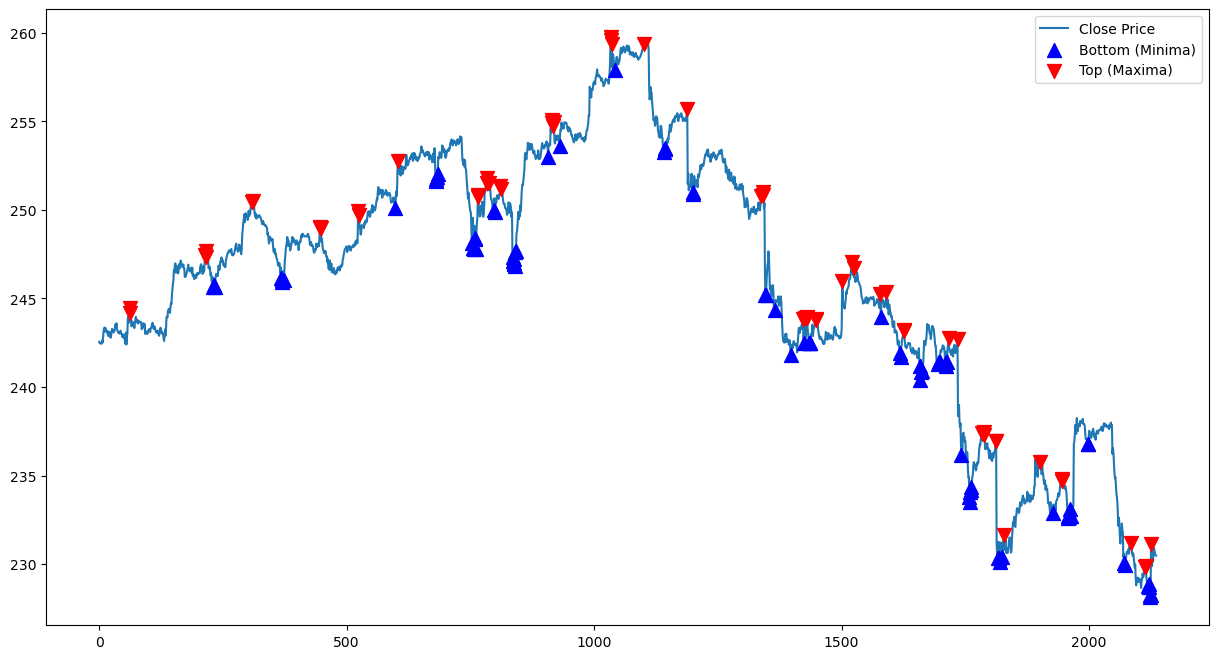

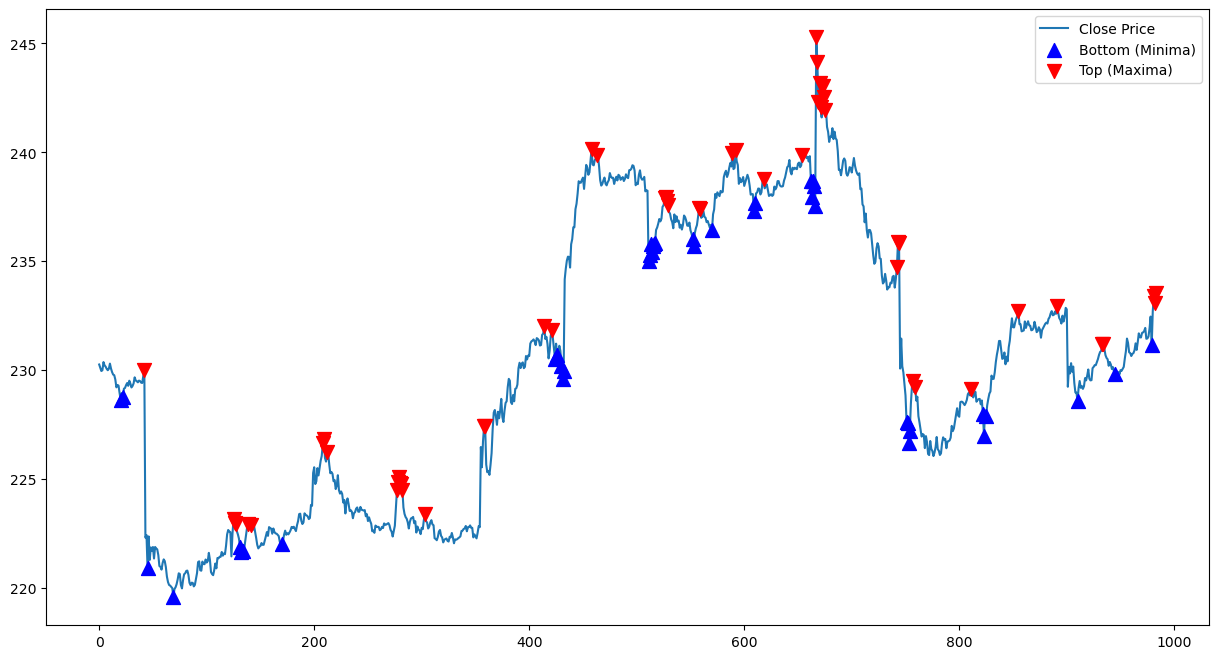

In [35]:
train_labels = find_turning_point_labels(train_y_gan_cl, classification_label_size, smoothing_threshold)
test_labels = find_turning_point_labels(test_y_gan_cl, classification_label_size, smoothing_threshold)

In [36]:
# Check for conflicting labels
conflicting_indices = np.where((train_labels == 2) & (train_labels == 1))[0]

# Print the indices of conflicts
if len(conflicting_indices) > 0:
    print("Conflicting labels found at indices:", conflicting_indices)
else:
    print("No conflicting labels found.")

No conflicting labels found.


In [19]:
def calc_labels(labels):
    """
    Calculates unique label counts and prints the relevant labels with counts.

    Arguments:
    - labels: Tensor containing class labels (2 for bottoms, 1 for tops, 0 for neutral).

    Returns:
    - label_counts_dict: Dictionary mapping labels to their counts.
    """

    # Convert PyTorch tensor to NumPy array
    labels_np = labels.numpy()

    # Get unique labels and their counts
    unique_labels, label_counts = np.unique(labels_np, return_counts=True)

    # Create a dictionary to store counts with their corresponding labels
    label_counts_dict = {int(label): count for label, count in zip(unique_labels, label_counts)}

    # Print counts with meaningful labels
    print("\nLabel Distribution:")
    for label, count in label_counts_dict.items():
        label_name = "Bottom (2)" if label == 2 else "Top (1)" if label == 1 else "Neutral (0)"
        print(f"{label_name}: {count}")

    return label_counts_dict  # Return dictionary for further use if needed


In [37]:
train_label_count = calc_labels(train_labels)
test_label_count = calc_labels(test_labels)


Label Distribution:
Neutral (0): 1988
Top (1): 62
Bottom (2): 86

Label Distribution:
Neutral (0): 891
Top (1): 53
Bottom (2): 40


### Turning Point Classifier Implementation - XGBoost

In [21]:
# spw = train_bottom_count[0]/train_bottom_count[1]
device = 'cpu'

def xgboost_train(x,y,eta=0.1):
    x = x.reshape(x.shape[0], -1)
    adasyn = ADASYN(sampling_strategy="auto", random_state=42)
    x, y = adasyn.fit_resample(x.detach().cpu().numpy(), y.detach().cpu().numpy())
    model= xgb.XGBClassifier(
        n_estimators=700, 
        max_depth=7, 
        learning_rate=0.1,
        # objective='binary:logistic',
        # eval_metric='aucpr',
        objective='multi:softmax', num_class=3, eval_metric="mlogloss",
        subsample = 0.1,
        colsample_bytree = 0.15,
        min_child_weight= 15,
        reg_alpha=0.7,
    )
    model.fit(x,y)
    return model
        
def xgboost_test(x, xgmodel):
    out_gru_3_xg = x.reshape(x.shape[0], -1)
    pred = xgmodel.predict(out_gru_3_xg.detach().cpu().numpy())
    pred = torch.tensor(pred).reshape(pred.shape[0],1)
    return pred

### Test with pretrained GAN model

In [38]:
# learning_rate_xgboost2 = 0.3

device = "cuda" if torch.cuda.is_available() else "cpu"
modelG2 = Generator(train_x.shape[1]).to(device)
modelG2.load_state_dict((torch.load("./Trained_models/WGAN_Generator.pth",map_location=device))["model_state_dict"])
modelG2.eval()

_,train_input_features = modelG2(train_x_slide.to(device))
train_input_features = torch.cat((train_input_features, new_feature_tensor_train.to(device)), dim=2)

_,test_input_features = modelG2(test_x_slide.to(device))
test_input_features = torch.cat((test_input_features, new_feature_tensor_test.to(device)), dim=2)

C:\Users\usith\AppData\Local\Temp\ipykernel_20024\3768415720.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelG2.load_state_dict((torch.load("./Trained_models/WGAN_G

In [39]:
xgb_model = xgboost_train(train_input_features,train_labels)

In [40]:
pred_train = xgboost_test(train_input_features, xgb_model)
print(classification_report(train_labels, pred_train, target_names=["Neutral (0)", "Top (1)", "Bottom (2)"]))

              precision    recall  f1-score   support

 Neutral (0)       1.00      0.87      0.93      1988
     Top (1)       0.33      0.97      0.49        62
  Bottom (2)       0.39      0.97      0.56        86

    accuracy                           0.88      2136
   macro avg       0.57      0.94      0.66      2136
weighted avg       0.95      0.88      0.90      2136



In [41]:
pred_test = xgboost_test(test_input_features, xgb_model)
print(classification_report(test_labels, pred_test, target_names=["Neutral (0)", "Top (1)", "Bottom (2)"]))

              precision    recall  f1-score   support

 Neutral (0)       0.92      0.48      0.63       891
     Top (1)       0.08      0.49      0.14        53
  Bottom (2)       0.12      0.55      0.19        40

    accuracy                           0.48       984
   macro avg       0.37      0.51      0.32       984
weighted avg       0.84      0.48      0.59       984



In [42]:
xgb_model.save_model("./Trained_models/TP_Classifier_AAPL.model")

c:\Users\usith\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:58:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


In [43]:
calc_labels(pred_train)
calc_labels(pred_test)


Label Distribution:
Neutral (0): 1742
Top (1): 181
Bottom (2): 213

Label Distribution:
Neutral (0): 468
Top (1): 330
Bottom (2): 186


{0: 468, 1: 330, 2: 186}

In [28]:
def show_confusion_matrix(y_true, y_pred, labels, display_labels=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix', fontsize=15, pad=20)
    plt.xlabel('Prediction', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.gca().xaxis.set_label_position('top')
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

    plt.show()

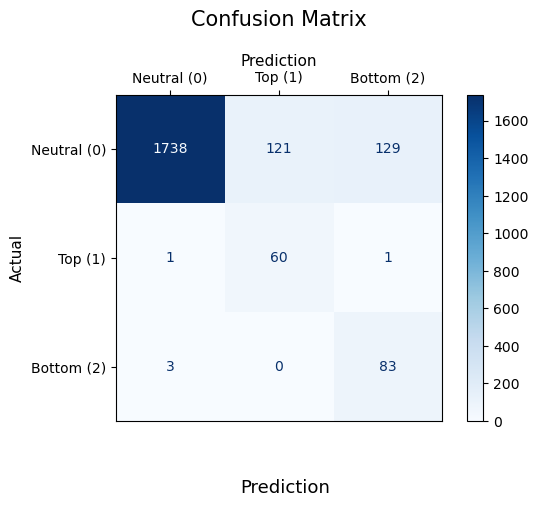

In [44]:
show_confusion_matrix(train_labels, pred_train, labels=[0, 1, 2], display_labels=["Neutral (0)", "Top (1)", "Bottom (2)"])

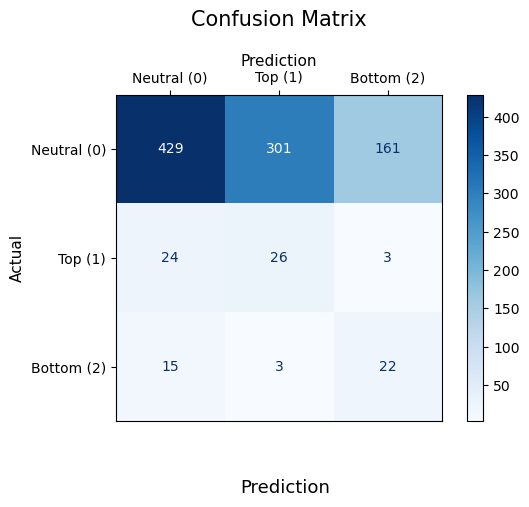

In [45]:
show_confusion_matrix(test_labels, pred_test, labels=[0, 1, 2], display_labels=["Neutral (0)", "Top (1)", "Bottom (2)"])

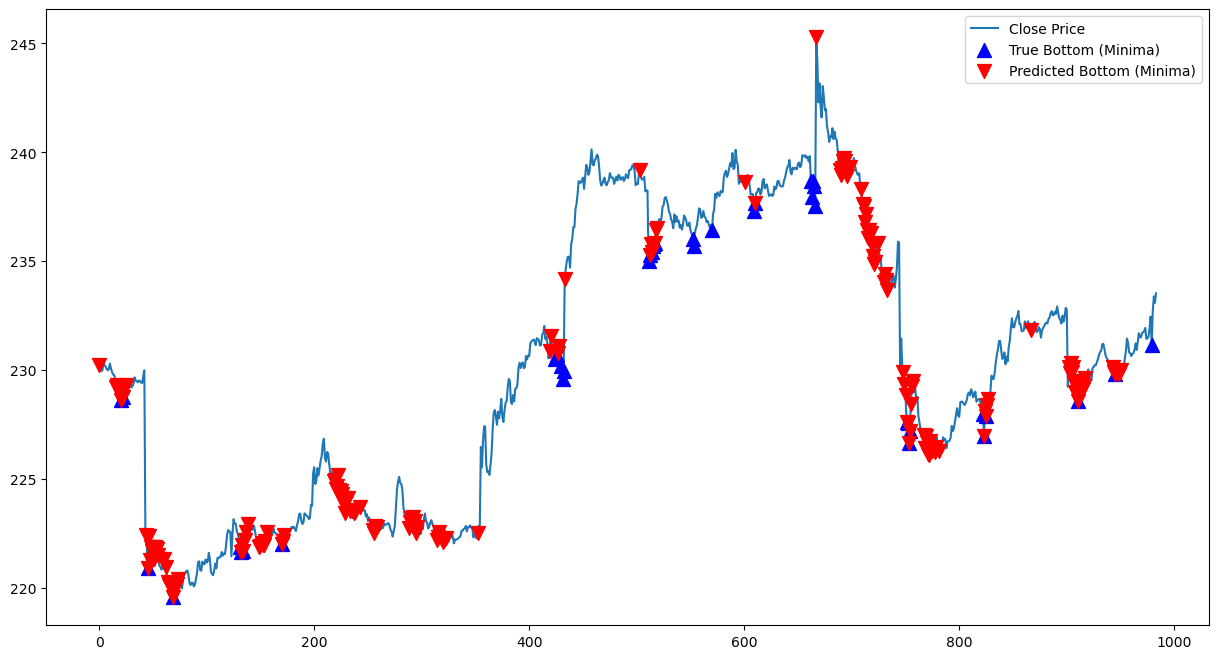

In [ ]:
values = test_y_gan_cl[:, classification_label_size, :]
y_labels_true = test_labels.numpy()
y_labels_pred = pred_test.numpy()
plt.figure(figsize=(15, 8))
plt.plot(values.numpy(), label="Close Price", zorder=0)

# True Bottoms
true_bottom_indices = np.where(y_labels_true == 2)[0]  # Indices where it's a bottom
if len(true_bottom_indices) > 0:
    plt.scatter(true_bottom_indices, values.numpy()[true_bottom_indices], 
                label="True Bottom (Minima)", s=100, color='blue', marker='^')

# Predicted Bottoms
pred_bottom_indices = np.where(y_labels_pred == 2)[0]  # Indices where it's a bottom
if len(pred_bottom_indices) > 0:
    plt.scatter(pred_bottom_indices, values.numpy()[pred_bottom_indices], 
                label="Predicted Bottom (Minima)", s=100, color='red', marker='v')
plt.legend()
plt.show()


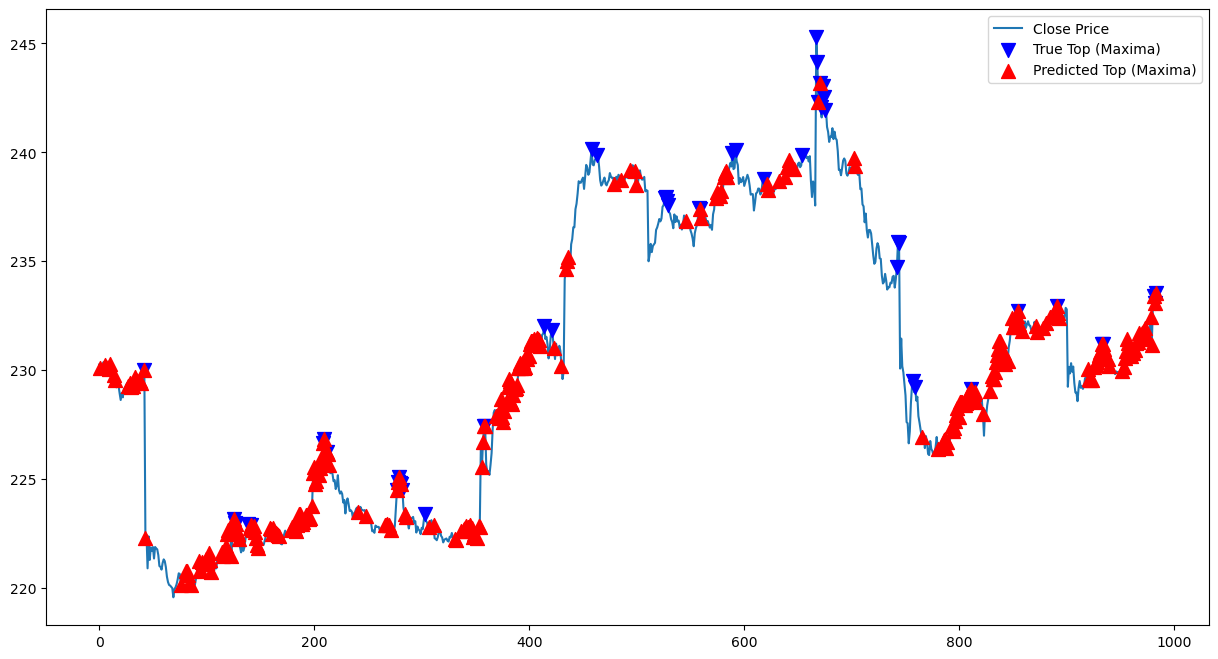

In [47]:
plt.figure(figsize=(15, 8))
plt.plot(values.numpy(), label="Close Price", zorder=0)

# True Tops
true_top_indices = np.where(y_labels_true == 1)[0]  # Indices where it's a top
if len(true_top_indices) > 0:
    plt.scatter(true_top_indices, values.numpy()[true_top_indices], 
                label="True Top (Maxima)", s=100, color='blue', marker='v')

# Predicted Tops
pred_top_indices = np.where(y_labels_pred == 1)[0]  # Indices where it's a top
if len(pred_top_indices) > 0:
    plt.scatter(pred_top_indices, values.numpy()[pred_top_indices], 
                label="Predicted Top (Maxima)", s=100, color='red', marker='^')
plt.legend()
plt.show()